# Projet Scoring

### Importation des libraries :

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm
import numpy as np
from typing import Dict, Tuple, Any
from sklearn.metrics import roc_curve, roc_auc_score

# ETAPE 1 : EDA

In [3]:
df = pd.read_csv("../data/credit_risk_dataset.csv", sep=',')

In [115]:
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3
1,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2
2,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3
3,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2
4,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.000,PERSONAL,C,5800,13.160,0,0.110,N,30
32577,54,120000,MORTGAGE,4.000,PERSONAL,A,17625,7.490,0,0.150,N,19
32578,65,76000,RENT,3.000,HOMEIMPROVEMENT,B,35000,10.990,1,0.460,N,28
32579,56,150000,MORTGAGE,5.000,PERSONAL,B,15000,11.480,0,0.100,N,26


In [116]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

| Variable                         | Description                                                                 | Type            |
|----------------------------------|-----------------------------------------------------------------------------|-----------------|
| person_age                       | Âge de la personne (en années)                                               | Numérique       |
| person_income                    | Revenu annuel de la personne                                                 | Numérique       |
| person_home_ownership            | Statut de logement de la personne (RENT, OWN, MORTGAGE, OTHER)               | Catégorielle    |
| person_emp_length                | Ancienneté professionnelle (en années)                                      | Numérique       |
| loan_intent                      | Objet du prêt (EDUCATION, MEDICAL, PERSONAL, VENTURE, etc.)                 | Catégorielle    |
| loan_grade                       | Note de crédit du prêt (A = meilleur, G = plus risqué)                      | Ordinale        |
| loan_amnt                        | Montant du prêt demandé                                                      | Numérique       |
| loan_int_rate                    | Taux d’intérêt du prêt (en %)                                                | Numérique       |
| loan_status                      | Statut du prêt (1 = défaut / non-remboursement, 0 = remboursement normal)  | Binaire         |
| loan_percent_income              | Part du revenu annuel consacrée au remboursement du prêt                     | Numérique       |
| cb_person_default_on_file        | Historique de défaut de paiement (Y = oui, N = non)                          | Binaire         |
| cb_person_cred_hist_length       | Ancienneté de l’historique de crédit (en années)                             | Numérique       |


In [4]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000,32581.000,31686.000,32581.000,29465.000,32581.000,32581.000,32581.000
mean,27.735,66074.848,4.790,9589.371,11.012,0.218,0.170,5.804
std,6.348,61983.119,4.143,6322.087,3.240,0.413,0.107,4.055
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38500.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79200.000,7.000,12200.000,13.470,0.000,0.230,8.000
max,144.000,6000000.000,123.000,35000.000,23.220,1.000,0.830,30.000


In [5]:
df["person_age"].sort_values(ascending=False).head(10)

183      144
32297    144
81       144
747      123
575      123
32416     94
32506     84
32422     80
32355     78
32534     76
Name: person_age, dtype: int64

Cette variable représente l’âge approximatif auquel la personne a commencé à avoir un historique de crédit :

- Un mineur ne peut pas avoir un crédit personnel
- Il ne peut pas avoir d’historique de crédit à son nom
- Toute observation suggérant le contraire est invalide

In [6]:
df["age_credit_gap"] = df["person_age"] - df["cb_person_cred_hist_length"]
df[df["age_credit_gap"] < 18].shape[0]


781

In [120]:
df[df["age_credit_gap"] < 18]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_credit_gap
35,21,12000,OWN,5.000,EDUCATION,A,2500,7.510,1,0.210,N,4,17
60,21,131000,RENT,0.000,VENTURE,A,30000,5.990,0,0.230,N,4,17
77,21,12000,OWN,0.000,PERSONAL,C,4200,13.480,1,0.350,Y,4,17
148,21,13200,OWN,0.000,VENTURE,C,4500,12.980,1,0.340,N,4,17
167,21,200000,MORTGAGE,5.000,EDUCATION,C,16000,14.650,0,0.080,N,4,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28815,27,49000,MORTGAGE,11.000,MEDICAL,B,8500,10.590,0,0.170,N,10,17
29021,27,56253,RENT,11.000,HOMEIMPROVEMENT,B,10000,11.360,0,0.180,N,10,17
29035,27,40000,RENT,4.000,VENTURE,D,10000,NaN,0,0.250,Y,10,17
29043,27,84000,MORTGAGE,3.000,DEBTCONSOLIDATION,A,7000,7.290,0,0.080,N,10,17


In [7]:
df = df[df["age_credit_gap"] >= 18]

In [122]:
df.shape

(31800, 13)

In [8]:
df["person_age"].sort_values(ascending=False).head(20)

183      144
32297    144
81       144
575      123
747      123
32416     94
32506     84
32422     80
32355     78
32534     76
32432     73
32521     73
32381     73
32385     70
32436     70
32360     70
32522     70
32383     70
32334     70
32532     70
Name: person_age, dtype: int64

actuellement 117 ans la plus vielle personne

In [9]:
df = df[df["person_age"]<=100]

In [10]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,age_credit_gap
count,31795.000,31795.000,30925.000,31795.000,28749.000,31795.000,31795.000,31795.000,31795.000
mean,27.814,66143.633,4.808,9614.883,11.011,0.218,0.170,5.779,22.035
std,6.232,52861.491,4.111,6329.044,3.242,0.413,0.107,4.073,3.227
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000,18.000
25%,23.000,39000.000,2.000,5000.000,7.900,0.000,0.090,3.000,20.000
50%,26.000,55004.000,4.000,8000.000,10.990,0.000,0.150,4.000,21.000
75%,30.000,80000.000,7.000,12250.000,13.470,0.000,0.230,8.000,23.000
max,94.000,2039784.000,123.000,35000.000,23.220,1.000,0.830,30.000,67.000


In [11]:
df["person_emp_length"].sort_values(ascending=False).head(20)

0       123.000
32355    41.000
32515    38.000
32428    34.000
32263    31.000
31867    31.000
30914    31.000
31866    31.000
32562    30.000
32539    30.000
32480    29.000
31203    28.000
32142    28.000
30844    28.000
32503    27.000
30646    27.000
32379    27.000
30776    27.000
31646    27.000
31830    26.000
Name: person_emp_length, dtype: float64

In [12]:
df["age_emp_gap"] = df["person_age"] - df["person_emp_length"]
df[df["age_emp_gap"] < 16].shape[0]

722

In [13]:
df = df[df["age_emp_gap"] >= 16]

In [14]:
df.shape

(30203, 14)

In [15]:
df["person_emp_length"].sort_values(ascending=False).head(20)

32355   41.000
32428   34.000
31866   31.000
30914   31.000
32539   30.000
32562   30.000
32480   29.000
30844   28.000
31203   28.000
32142   28.000
32379   27.000
31646   27.000
30776   27.000
30646   27.000
32503   27.000
31888   26.000
31042   26.000
30260   26.000
30171   26.000
31830   26.000
Name: person_emp_length, dtype: float64

In [16]:
df[df["person_emp_length"] > df["person_age"]].shape[0]

0

In [17]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,age_credit_gap,age_emp_gap
count,30203.000,30203.000,30203.000,30203.000,27302.000,30203.000,30203.000,30203.000,30203.000,30203.000
mean,27.896,66723.227,4.682,9668.953,11.043,0.215,0.169,5.822,22.074,23.214
std,6.273,53385.257,3.986,6345.654,3.228,0.411,0.106,4.100,3.246,6.809
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000,18.000,16.000
25%,23.000,39600.000,2.000,5000.000,7.900,0.000,0.090,3.000,20.000,18.000
50%,26.000,56000.000,4.000,8000.000,10.990,0.000,0.150,4.000,21.000,22.000
75%,30.000,80000.000,7.000,12500.000,13.480,0.000,0.230,8.000,23.000,26.000
max,94.000,2039784.000,41.000,35000.000,23.220,1.000,0.830,30.000,67.000,93.000


83 % du revenu annuel consacré au prêt

In [18]:
df.shape

(30203, 14)

In [19]:
column_num = df.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df.select_dtypes(include=['object']).columns.drop('loan_grade')

- On séléctionne toutes les variables numérique et drop loan_status
- on séléctionne toutes les variables catégorielles et drop loan_grade

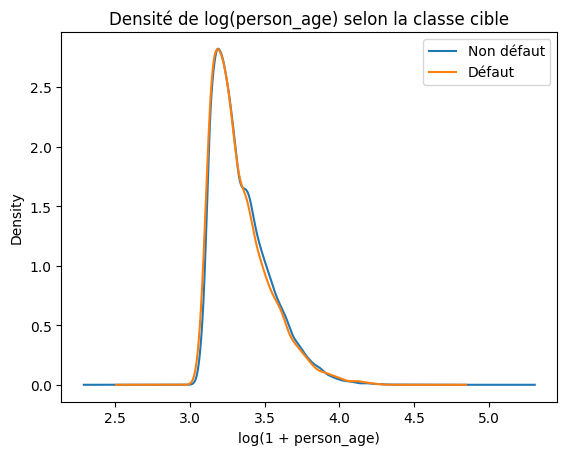

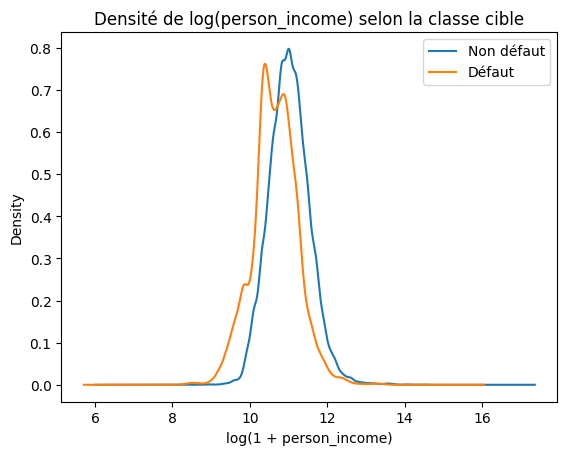

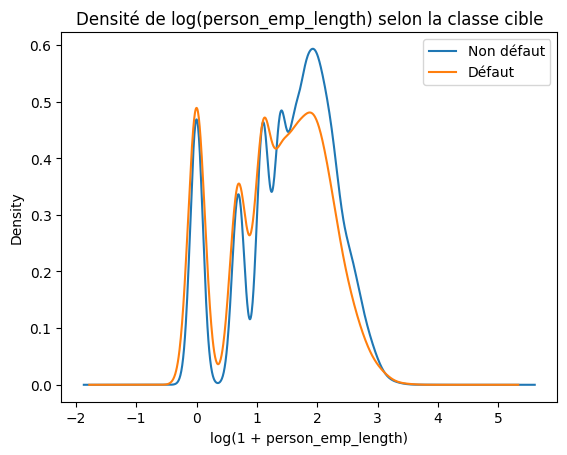

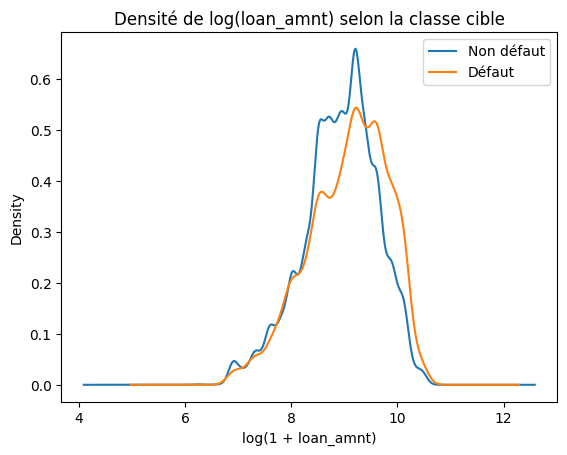

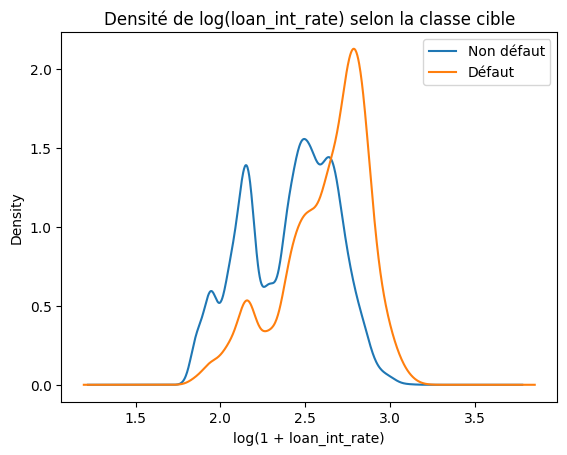

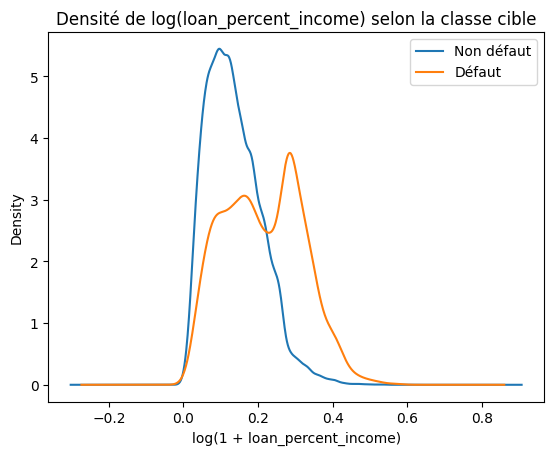

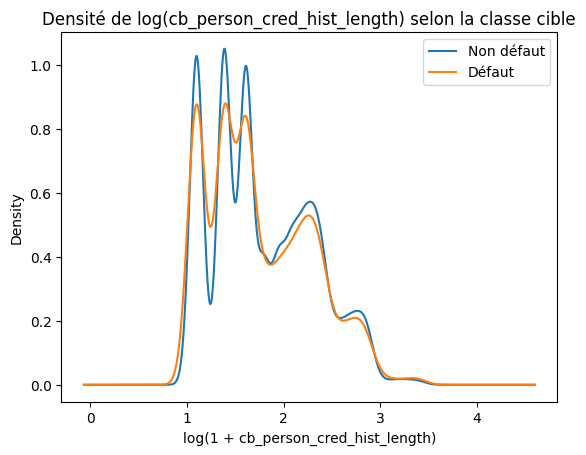

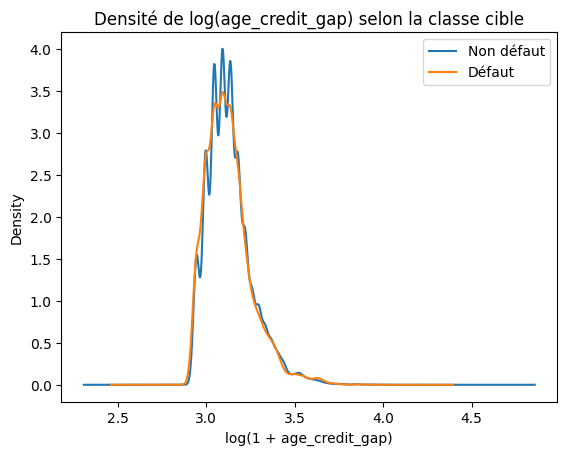

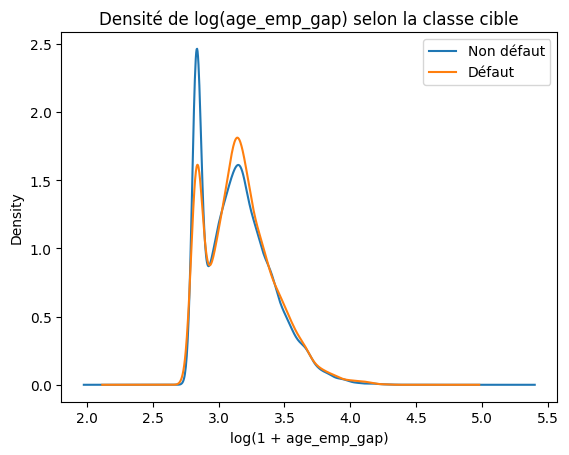

In [20]:
import numpy as np
for col in column_num:
    plt.figure()

    x0 = df.loc[df['loan_status'] == 0, col]
    x1 = df.loc[df['loan_status'] == 1, col]

    np.log1p(x0).dropna().plot(kind='density', label='Non défaut')
    np.log1p(x1).dropna().plot(kind='density', label='Défaut')

    plt.title(f'Densité de log({col}) selon la classe cible')
    plt.xlabel(f'log(1 + {col})')
    plt.legend()
    plt.show()


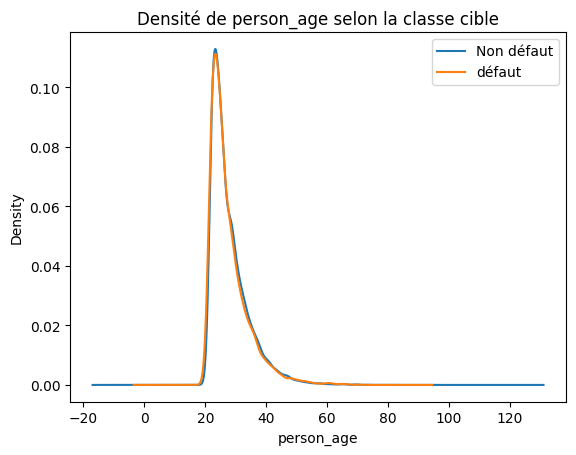

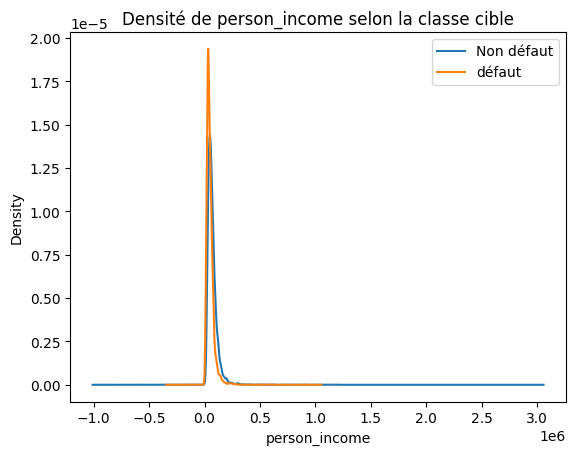

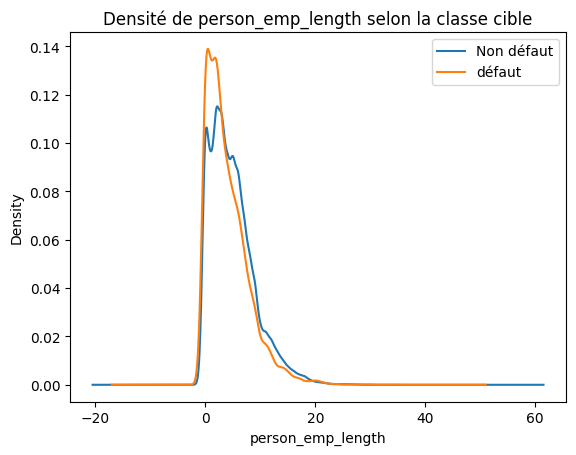

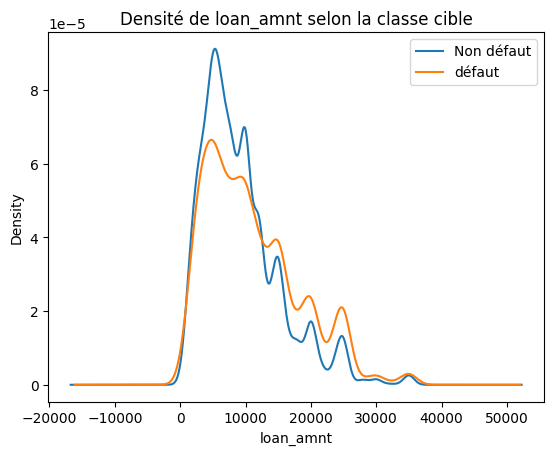

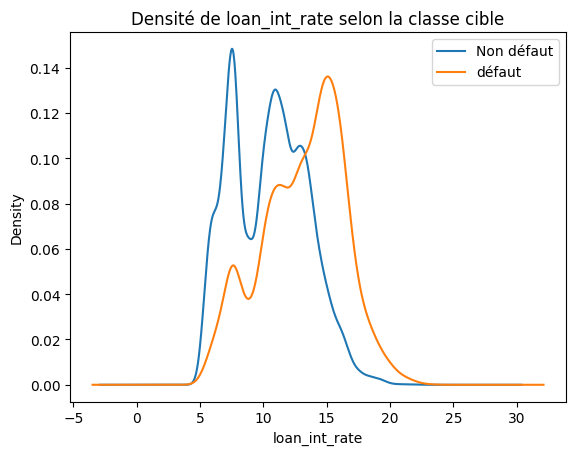

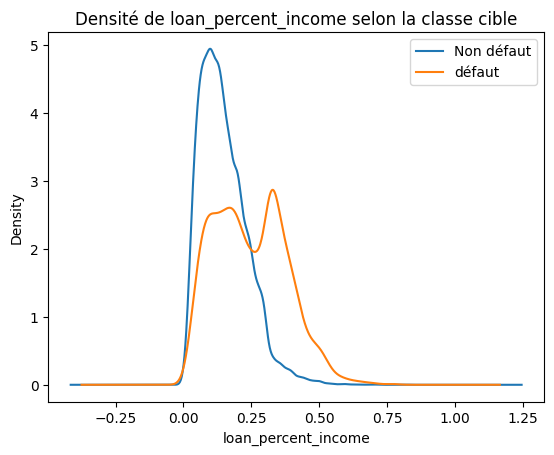

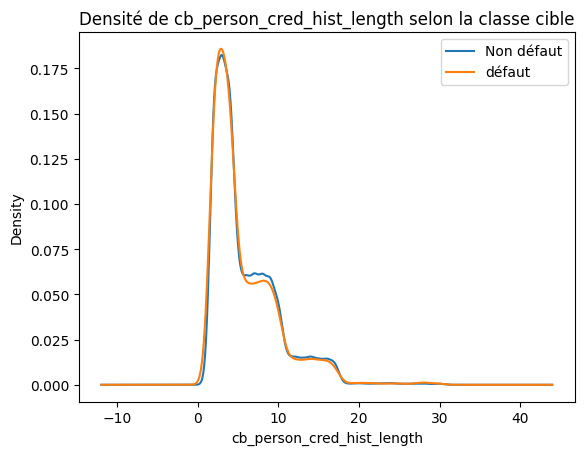

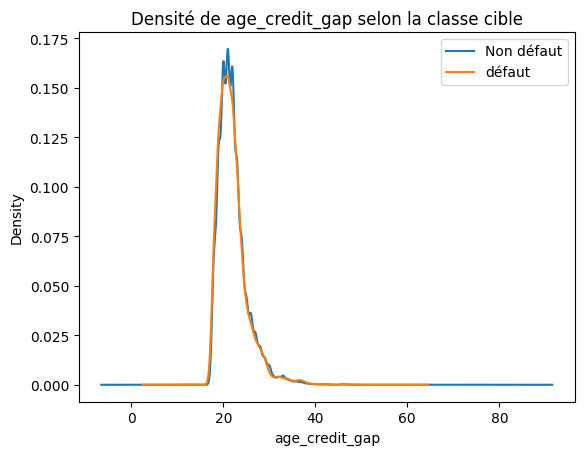

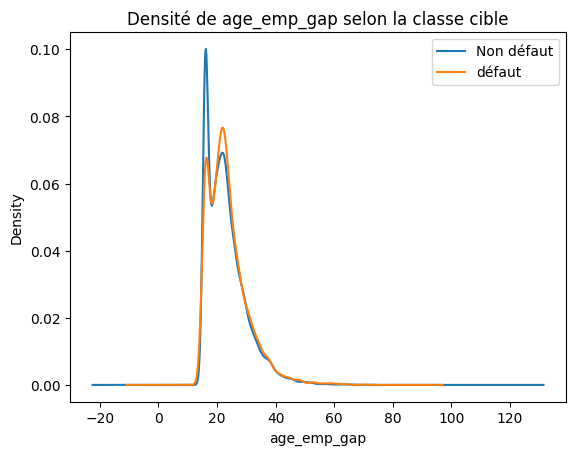

In [21]:
for col in column_num:
    plt.figure()
    df[df['loan_status']==0][col].plot(kind='density', label='Non défaut')
    df[df['loan_status']==1][col].plot(kind='density', label='défaut')
    plt.title(f'Densité de {col} selon la classe cible')
    plt.xlabel(col)
    plt.legend()
    plt.show()

**Test de Kolmogorov :**

- Pour chaque variable explicative, on teste si sa distribution est la même chez :
    - les non-défaillants (loan_status = 0)
    - les défaillants (loan_status = 1)

Si les distributions sont identiques ou très proches :
- la variable ne discrimine pas → elle sert peu en scoring.

In [22]:
ks_results = []

for col in column_num:
    # Séparer les groupes
    data0 = df[df['loan_status'] == 0][col].dropna()
    data1 = df[df['loan_status'] == 1][col].dropna()
    
    # Test KS
    stat, p_value = ks_2samp(data0, data1)
    
    ks_results.append({
        'variable': col,
        'KS_stat': stat,
        'p_value': p_value
    })

ks_df = pd.DataFrame(ks_results).sort_values(by='KS_stat', ascending=False)
print(ks_df)

## Les distributions ne sont pas indentiques (p_value < 0,05)

                     variable  KS_stat  p_value
5         loan_percent_income    0.352    0.000
4               loan_int_rate    0.343    0.000
1               person_income    0.273    0.000
3                   loan_amnt    0.126    0.000
2           person_emp_length    0.112    0.000
8                 age_emp_gap    0.052    0.000
0                  person_age    0.032    0.000
7              age_credit_gap    0.030    0.000
6  cb_person_cred_hist_length    0.029    0.000


### Decoupage en train et test

- On crée un Train et un Test set : En stratifiant selon les variables catégorielles et la variables cible
- On force pour que chaque type de client apparaisse dans le train ET dans le test dans les mêmes proportions

In [23]:
# On crée la variable de stratification en concatenant les colonnes des variables catégorielle
# On s'assure aussi que ce soit stratifié selon la variable cible
df['label_loan_status'] = df['loan_status'].astype('category')
df["stratify_col"] = df["label_loan_status"].astype(str) + "_" + df["person_home_ownership"].astype(str) + "_" + df["loan_intent"].astype(str) + "_" + df["cb_person_default_on_file"].astype(str)
df = df.drop(columns=["label_loan_status"])

On regroupe les profils clients rares afin de permettre une stratification correcte lors du découpage train/test.

- stratify_col = types de clients
- certains types apparaissent 1 seule fois
- impossible de stratifier avec ça
- on les met tous dans "Other"

In [24]:
# On regroupe les labels rares (qui on qu'une seule modalité) ensemble, pour pouvoir spliter
counts = df["stratify_col"].value_counts()
rare_labels = counts[counts < 2].index
df["stratify_col"] = df["stratify_col"].replace(rare_labels, "Other")

Le découpage train/test permet d’évaluer la capacité du modèle de scoring à prédire le défaut sur des emprunteurs jamais observés.

In [25]:
df_train_set, df_test_set = train_test_split(df, test_size=0.2, stratify=df["stratify_col"], random_state=42)
df_train_set = df_train_set.drop(columns=["stratify_col"])
df_test_set = df_test_set.drop(columns=["stratify_col"])

In [141]:
# print((df_train_set["loan_status"].value_counts())/len(df_train_set))
# print((df_test_set["loan_status"].value_counts())/len(df_test_set))
# (df["loan_status"].value_counts())/len(df)

## Exploration de la base de donnée

In [26]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

column_num = df_train_set.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df_train_set.select_dtypes(include=['object']).columns.drop('loan_grade')
df_train_set.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,age_credit_gap,age_emp_gap
count,24162.000,24162.000,24162.000,24162.000,21873.000,24162.000,24162.000,24162.000,24162.000,24162.000
mean,27.912,66880.627,4.661,9674.781,11.042,0.215,0.169,5.830,22.082,23.251
std,6.325,54996.302,3.970,6351.520,3.231,0.411,0.106,4.120,3.272,6.867
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000,18.000,16.000
25%,23.000,39675.000,2.000,5000.000,7.900,0.000,0.090,3.000,20.000,18.000
50%,26.000,56000.000,4.000,8000.000,10.990,0.000,0.150,4.000,21.000,22.000
75%,30.000,80000.000,7.000,12437.500,13.480,0.000,0.230,8.000,23.000,26.000
max,94.000,2039784.000,41.000,35000.000,22.480,1.000,0.830,30.000,67.000,93.000


In [27]:
df_train_set["person_income"].sort_values(ascending=False).head(20)

30049    2039784
32546    1900000
32497    1782000
31924    1440000
31922    1362000
17833    1200000
29120    1200000
17834     948000
32298     900000
31921     900000
29122     900000
29345     889000
32037     828000
31919     828000
31918     800000
30536     780000
31916     780000
32544     780000
27884     762000
28253     762000
Name: person_income, dtype: int64

In [144]:
# df_train_set_del_missing_variable = df_train_set[(~df_train_set['loan_int_rate'].isna())&(~df_train_set['person_emp_length'].isna())].copy()
# df_train_set_del_loan_int_rate = df_train_set[~df_train_set['loan_int_rate'].isna()].copy()
# df_train_set_del_person_emp_length = df_train_set[~df_train_set['person_emp_length'].isna()].copy()

# Etape 2 : Discrétisation et Regroupement

In [28]:
dff = df_train_set.copy()

In [146]:
dff.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'age_credit_gap', 'age_emp_gap'],
      dtype='object')

- Visualisation de la discrétisation avec Optimal Binning

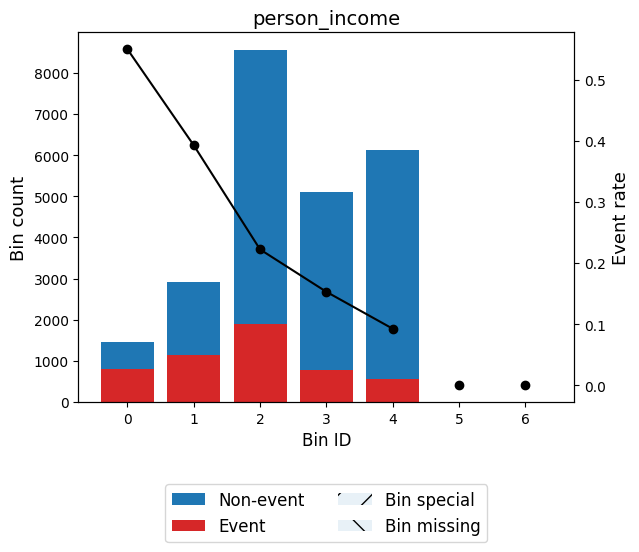

In [29]:
## GROUPEMENT VAR QUANT : L'IV mesure la capacité d’une variable à discriminer les bons et les mauvais payeurs (< 0.02 : inutile).
variable = 'person_income'
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", min_n_bins=5, max_n_bins=5)  # "cp" = solver par défaut (constraint programming)
optb.fit(dff[variable], dff['loan_status'])

bin_table = optb.binning_table.build()
# print(bin_table)
optb.binning_table.plot(metric="event_rate")

In [30]:
# loan_intent, person_home_ownership
variable = 'loan_intent'
optb = OptimalBinning(name=variable, dtype='categorical', max_n_bins=4)
optb.fit(dff[variable], dff['loan_status'])
print(optb.binning_table.build())   # voir les groupes, WoE, IV

                                                  Bin  Count  Count (%)  \
0                                           [VENTURE]   4229      0.175   
1                                         [EDUCATION]   4753      0.197   
2                                          [PERSONAL]   4109      0.170   
3       [HOMEIMPROVEMENT, MEDICAL, DEBTCONSOLIDATION]  11071      0.458   
4                                             Special      0      0.000   
5                                             Missing      0      0.000   
Totals                                                 24162      1.000   

        Non-event  Event  Event rate    WoE    IV    JS  
0            3605    624       0.148  0.459 0.032 0.004  
1            3946    807       0.170  0.292 0.015 0.002  
2            3320    789       0.192  0.142 0.003 0.000  
3            8095   2976       0.269 -0.294 0.043 0.005  
4               0      0       0.000  0.000 0.000 0.000  
5               0      0       0.000  0.000 0.000 0

In [149]:
# ## GROUPEMENT VAR QUAL
# var = "classe_loan_intent"
# print((dff[var].value_counts())/len(dff))
# dff.groupby(dff[var])["loan_status"].mean()

In [31]:
########################### FONCTIONS POUR DISCRETISER  ##########################################################
## Variable Age
def cat_age(data:pd.DataFrame, nb_classe:int) -> pd.DataFrame:    ## Tester avec 3 et 2 classes
    if nb_classe==3:
        conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 28.50,
                  ((data["person_age"] >= 22.50) & (data["person_age"] < 28.50))             
              ]
        choix_age = ["Jeunes instables", "seniors", "Jeunes"]
        data["classe_age"] = np.select(conditions_age, choix_age, default=None)  
    elif nb_classe==2:
         conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 22.50          
              ]
         choix_age = ["Juniors", "seniors"]
         data["classe_age_2"] = np.select(conditions_age, choix_age, default=None)
    return data

def cat_income(data):
    conditions_income = [data["person_income"] < 22806.00,
                     data["person_income"] >= 79993.50,
                     (data["person_income"] >= 59853.50) & (data["person_income"] < 79993.50),
                     (data["person_income"] >= 34990.00) & (data["person_income"] < 59853.50),
                     (data["person_income"] >= 22806.00) & (data["person_income"] < 34990.00)                               
              ]
    choix_income = ["(-inf, 22806.00)", "[79993.50, inf)", "[59853.50, 79993.50)", "[34990.00, 59853.50)", "[22806.00, 34990.00)"]
    data["classe_income"] = np.select(conditions_income, choix_income, default=None) # Relation monotone décroissante
    return data

def cat_emp_length(data, nb_classe):
    if nb_classe == 5:
        conditions_emp = [data["person_emp_length"].isna(),
                  data["person_emp_length"] < 1.50,
                  data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]

        choix_emp = ["Missing","(-inf, 1.50)", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 4:
        conditions_emp = [(data["person_emp_length"].isna())|(data["person_emp_length"] < 1.50),  # 2 ème cas : je regroupe les sans_emploi et courte durée d'emploi              
                 data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]
        choix_emp = ["no_emp et < 1.50", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp_2"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_emp_length_imputed(data, nb_classe):
    if nb_classe == 4:
        conditions_emp = [data["emp_imputed"] < 2.50,
                  data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 4.50) & (data["emp_imputed"] < 7.50),
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 4.50)
              ]

        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[4.50, 7.50)", "[2.50, 4.50)"]
        data["classe_emp_imp_4"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 3:
        conditions_emp = [data["emp_imputed"] < 2.50,        
                 data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 7.50)
              ]
        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[2.50, 7.50)"]
        data["classe_emp_imp_3"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_amnt(data):
    conditions_amnt = [data["loan_amnt"] < 5012.50,
                     data["loan_amnt"] >= 18087.50,
                     (data["loan_amnt"] >= 14062.50) & (data["loan_amnt"] < 18087.50),
                     (data["loan_amnt"] >= 7487.50) & (data["loan_amnt"] < 14062.50),
                     (data["loan_amnt"] >= 5012.50) & (data["loan_amnt"] < 7487.50)                               
              ]

    choix_amnt = ["(-inf, 5012.50)", "[18087.50, inf)", "[14062.50, 18087.50)", "[7487.50, 14062.50)", "[5012.50, 7487.50)"]
    data["classe_amnt"] = np.select(conditions_amnt, choix_amnt, default=None)  # Relation en U (tester un autre regroupement si ce n'est pas significatif)
    return data

def cat_int_rate(data):
    conditions_int_rate = [data["loan_int_rate"].isna(),
                     data["loan_int_rate"] < 7.89,
                     data["loan_int_rate"] >= 15.28,
                     (data["loan_int_rate"] >= 14.37) & (data["loan_int_rate"] < 15.28),
                     (data["loan_int_rate"] >= 12.07) & (data["loan_int_rate"] < 14.37),
                     (data["loan_int_rate"] >= 7.89) & (data["loan_int_rate"] < 12.07)                               
              ]

    choix_int_rate = ["Missing","(-inf, 7.89)", "[15.28, inf)", "[14.37, 15.28)", "[12.07, 14.37)", "[7.89, 12.07)"]
    data["classe_int_rate"] = np.select(conditions_int_rate, choix_int_rate, default=None)  # Relation monotone croissante
    return data

def cat_percent_income(data):
    conditions_percent_income = [data["loan_percent_income"] < 0.16,
                     data["loan_percent_income"] >= 0.31,
                     (data["loan_percent_income"] >= 0.25) & (data["loan_percent_income"] < 0.31),
                     (data["loan_percent_income"] >= 0.16) & (data["loan_percent_income"] < 0.25)                               
              ]

    choix_percent_income = ["(-inf, 0.16)", "[0.31, inf)", "[0.25, 0.31)", "[0.16, 0.25)"]
    data["classe_percent_income"] = np.select(conditions_percent_income, choix_percent_income, default=None) # Relation monotone croissante
    return data

def cat_cred_hist_length(data):
    conditions_cred_hist = [data["cb_person_cred_hist_length"] < 2.50,
                     data["cb_person_cred_hist_length"] >= 4.50,
                     (data["cb_person_cred_hist_length"] >= 2.50) & (data["cb_person_cred_hist_length"] < 4.50)                               
              ]

    choix_cred_hist = ["(-inf, 2.50)", "[4.50, inf)", "[2.50, 4.50)"]
    data["classe_cred_hist"] = np.select(conditions_cred_hist, choix_cred_hist, default=None)
    return data


**On applique les fonctions de discrétisation :**

In [32]:

## Age
dff = cat_age(dff, 3) # IV : 0.01 < 0.02 inutile dans le modèle
# dff = cat_age(dff, 2)

## Variable person_income
dff = cat_income(dff)  # IV : 0.563203

## person_emp_length
# dff = cat_emp_length(dff, 5) # IV : 0.069434
#dff = cat_emp_length(dff, 4)

## loan_amnt
dff = cat_amnt(dff) # IV : 0.085453

## loan_int_rate
dff = cat_int_rate(dff) # IV : 0.665547

## loan_percent_income
dff = cat_percent_income(dff) # IV : 0.943946

## cb_person_cred_hist_length
dff = cat_cred_hist_length(dff) # IV : 0.003482

- Imputation de la variable person_emp_length (durée d'emploi) par la médiane conditionnelle

In [33]:
# On regarde de coeff de corrélation entre person_income et person_emp_length
# L'idée c'est d'imputer la durée de travail selon les classes des revenus des individus
corr_pearson = dff["person_emp_length"].corr(dff["person_income"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.14626810239152432


In [34]:
# Calcul des médianes de durée d'emploi par bin de revenu
median_emp_by_income = dff.groupby("classe_income")["person_emp_length"].median()

# Fonction d'imputation
def impute_emp(row):
    if pd.isna(row["person_emp_length"]):
        return median_emp_by_income.loc[row["classe_income"]]
    else:
        return row["person_emp_length"]

# Appliquer l’imputation
dff["emp_imputed"] = dff.apply(impute_emp, axis=1)

In [35]:
## emp_imputed
dff = cat_emp_length_imputed(dff, 4) # IV : 0.068035
# dff = cat_emp_length_imputed(dff, 3)

- Regroupement des variables catégorielles

In [36]:
## On regroupe "loan_intent" car trop de modalité et certaines qui on quasiment le même taux de défaut
## Surtout parce que sans regrouper, on a une modalité non significative dans la régression logistique
dff.groupby("loan_intent")["loan_status"].mean()

loan_intent
DEBTCONSOLIDATION   0.282
EDUCATION           0.170
HOMEIMPROVEMENT     0.254
MEDICAL             0.266
PERSONAL            0.192
VENTURE             0.148
Name: loan_status, dtype: float64

In [37]:
## Les modalités "OTHER" et "RENT" ont des taux de défaut très proches, donc on les regroupe
dff.groupby("person_home_ownership")["loan_status"].mean()

person_home_ownership
MORTGAGE   0.124
OTHER      0.317
OWN        0.068
RENT       0.310
Name: loan_status, dtype: float64

In [38]:
########################### FONCTIONS DE REGROUPEMENT  ##########################################################

def cat_home_ownership(data):
    data["classe_person_home_ownership"] = np.where((data["person_home_ownership"]=='OTHER')|(data["person_home_ownership"]=='RENT'), "[OTHER, RENT]", data["person_home_ownership"])
    return data

def cat_loan_intent(data):
    data["classe_loan_intent"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL'), "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

def cat_loan_intent_2(data):
    data["classe_loan_intent_2"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL')|(data["loan_intent"]=='DEBTCONSOLIDATION'),
                                           "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

In [39]:
###########################  Application des fonctions de regroupement aux variables qualitatives ###################################
## person_home_ownership
dff = cat_home_ownership(dff)

## loan_intent
# dff = cat_loan_intent(dff) # 0.095697
dff = cat_loan_intent_2(dff)

## cb_person_default_on_file
# Pour l'instant on ne touche pas  # 0.164053

# ETAPE 3 : Correlation des Variables

In [40]:
## Variables avec lesquelles on fait le régression logistique dans R (pour voir la significativité des coefficicents)
dff_reg = dff[['loan_status','classe_age','classe_income', 'classe_amnt','classe_int_rate', 'classe_percent_income', 'classe_cred_hist',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

**Test de significativité de la corrélation :**

In [41]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
## Calcul du V_de_Cramer et de la P_value
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    p = chi2_contingency(confusion_matrix)[1]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return [np.sqrt(chi2 / (n * (min(r, k) - 1))), p]

target = 'loan_status'
features = [col for col in dff_reg.columns if col != target]

corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
chi2_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
for var1 in features:
    for var2 in features:
        confusion = pd.crosstab(dff_reg[var1], dff_reg[var2])
        chi2_cramer = cramers_v(confusion)
        corr_matrix.loc[var1, var2] = chi2_cramer[0]
        chi2_matrix.loc[var1, var2] = chi2_cramer[1]

# P_value # < 0.05 (on rejette l'indépendance au seuil de 5%)
chi2_matrix

,classe_age,classe_income,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_age,0.000,0.000,0.000,0.490,0.000,0.000,0.000,0.000,0.233,0.000
classe_income,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.282
classe_amnt,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.132
classe_int_rate,0.490,0.000,0.000,0.000,0.000,0.010,0.000,0.000,0.000,0.177
classe_percent_income,0.000,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.710
classe_cred_hist,0.000,0.000,0.000,0.010,0.001,0.000,0.000,0.000,0.472,0.000
classe_emp_imp_4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
classe_person_home_ownership,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
cb_person_default_on_file,0.233,0.000,0.000,0.000,0.000,0.472,0.000,0.000,0.000,0.469
classe_loan_intent_2,0.000,0.282,0.132,0.177,0.710,0.000,0.000,0.000,0.469,0.000


**Intensité de la corrélation :**

In [42]:
# V_de_Cramer (>= 0.5 -> association forte)
corr_matrix

,classe_age,classe_income,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_age,1.000,0.108,0.049,0.014,0.035,0.568,0.167,0.036,0.011,0.088
classe_income,0.108,1.000,0.206,0.034,0.194,0.068,0.130,0.233,0.045,0.014
classe_amnt,0.049,0.206,1.000,0.085,0.335,0.039,0.065,0.090,0.058,0.016
classe_int_rate,0.014,0.034,0.085,1.000,0.077,0.022,0.050,0.103,0.537,0.017
classe_percent_income,0.035,0.194,0.335,0.077,1.000,0.022,0.031,0.096,0.042,0.009
classe_cred_hist,0.568,0.068,0.039,0.022,0.022,1.000,0.133,0.031,0.008,0.070
classe_emp_imp_4,0.167,0.130,0.065,0.050,0.031,0.133,1.000,0.180,0.037,0.036
classe_person_home_ownership,0.036,0.233,0.090,0.103,0.096,0.031,0.180,1.000,0.063,0.076
cb_person_default_on_file,0.011,0.045,0.058,0.537,0.042,0.008,0.037,0.063,1.000,0.010
classe_loan_intent_2,0.088,0.014,0.016,0.017,0.009,0.070,0.036,0.076,0.010,1.000


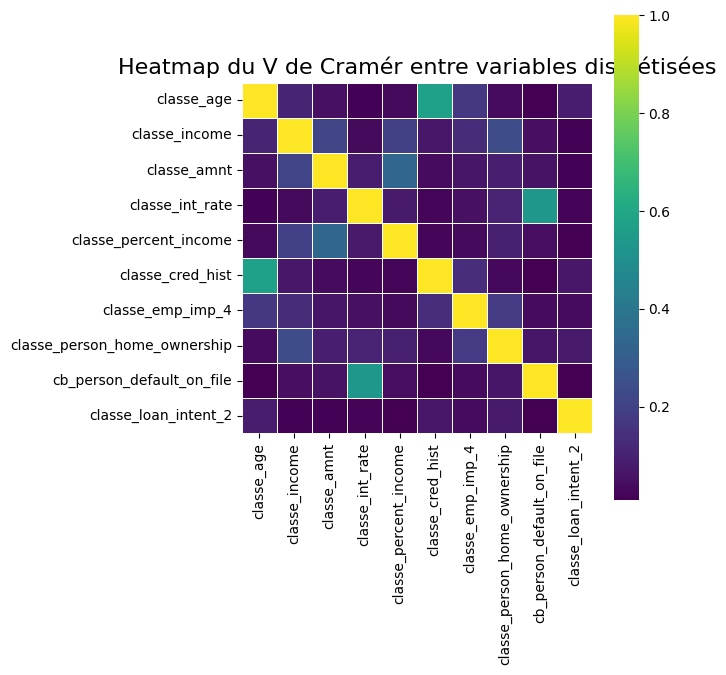

In [43]:
plt.figure(figsize=(7,7))
sns.heatmap(corr_matrix.astype(float),annot=False, cmap="viridis", square=True, linewidths=0.5)
plt.title("Heatmap du V de Cramér entre variables discrétisées", fontsize=16)
plt.tight_layout()
plt.show()

- forte association entre **classe_cred_hist** et **classe_age**
- forte association entre **cb_person_default_on_file** et **classe_int_rate**
- Association modérée entre **classe_person_income** et **classe_amnt**

In [45]:
## On remarque aussi que loan_percent_income = loan_amnt / loan_income (même s'il y'a quelques différences)
df["var"] = round(df["loan_amnt"]/df["person_income"], 2)
df[["var","loan_percent_income"]].head(10)

,var,loan_percent_income
1,0.100,0.100
2,0.570,0.570
3,0.530,0.530
4,0.640,0.550
5,0.250,0.250
6,0.450,0.450
7,0.440,0.440
8,0.420,0.420
10,0.410,0.410
11,0.450,0.450


In [46]:
corr_pearson = df["loan_percent_income"].corr(df["var"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.9991766907364966


In [47]:
results_chi2_loan_status = []
for var in features:
    confusion = pd.crosstab(dff_reg[var], dff_reg[target])
    n = confusion.sum().sum()
    r, k = confusion.shape
    chi2, p, dof, expected = chi2_contingency(confusion)
    v_cramer = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    results_chi2_loan_status.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p,
        'V_de_cramer' : v_cramer
    })
    
results_chi2_loan_status = pd.DataFrame(results_chi2_loan_status)
results_chi2_loan_status

,variable,chi2,p_value,V_de_cramer
0,classe_age,28.214,0.000,0.034
1,classe_income,2301.178,0.000,0.309
2,classe_amnt,422.598,0.000,0.132
3,classe_int_rate,3234.613,0.000,0.366
4,classe_percent_income,4641.812,0.000,0.438
5,classe_cred_hist,14.513,0.001,0.025
6,classe_emp_imp_4,240.828,0.000,0.100
7,classe_person_home_ownership,1377.596,0.000,0.239
8,cb_person_default_on_file,783.651,0.000,0.180
9,classe_loan_intent_2,374.291,0.000,0.124


- **Age** préféré à **cred_hist** *(IV_age > IV_cred_hist)*
- **loan_int_rate** préféré à **cb_person_default_on_file** *(IV_rate > IV_default_on_file)*

In [166]:
# Exportation de la table pour l'utiliser dans R (On fait la regression logistique sur R pour 
## voir clairement la significativité des variables)
dff_reg.to_csv("../data/df_reg.csv", sep=",", index=False, encoding="utf-8")

# ETAPE 4 : Régression Logistique

In [48]:
# Variables retenues pour le modèle
dff_reg = dff[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [168]:
## Base à utiliser pour le suite
# dff_reg.to_csv("../data/data.csv", sep=",", index=False, encoding="utf-8")

In [49]:
dff_reg = pd.read_csv("../data/data.csv")

In [170]:
# print(len(df))
# len(df_test_set) + len(dff_reg)

In [171]:
dff_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26059 entries, 0 to 26058
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   loan_status                   26059 non-null  int64 
 1   classe_income                 26059 non-null  object
 2   classe_int_rate               26059 non-null  object
 3   classe_percent_income         26059 non-null  object
 4   classe_emp_imp_4              26059 non-null  object
 5   classe_person_home_ownership  26059 non-null  object
 6   cb_person_default_on_file     26059 non-null  object
 7   classe_loan_intent_2          26059 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.6+ MB


In [50]:
features = dff_reg.select_dtypes(include=['object']).columns
target = "loan_status"
X = dff_reg[features]
y = dff_reg[target]

In [57]:
dff_reg

,loan_status,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
0,0,"[22806.00, 34990.00)","[7.89, 12.07)","(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE
1,0,"[34990.00, 59853.50)","(-inf, 7.89)","[0.16, 0.25)","(-inf, 2.50)","[OTHER, RENT]",N,PERSONAL
2,0,"[79993.50, inf)","[7.89, 12.07)","[0.16, 0.25)","[4.50, 7.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]"
3,0,"[34990.00, 59853.50)","[14.37, 15.28)","[0.31, inf)","[2.50, 4.50)",MORTGAGE,Y,EDUCATION
4,0,"[79993.50, inf)","(-inf, 7.89)","(-inf, 0.16)","[7.50, inf)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]"
...,...,...,...,...,...,...,...,...
26054,0,"[34990.00, 59853.50)","[12.07, 14.37)","(-inf, 0.16)","(-inf, 2.50)","[OTHER, RENT]",N,PERSONAL
26055,1,"[34990.00, 59853.50)","[15.28, inf)","[0.16, 0.25)","(-inf, 2.50)","[OTHER, RENT]",Y,VENTURE
26056,0,"[79993.50, inf)","[7.89, 12.07)","(-inf, 0.16)","[4.50, 7.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]"
26057,0,"[22806.00, 34990.00)","[7.89, 12.07)","[0.25, 0.31)","[2.50, 4.50)","[OTHER, RENT]",N,PERSONAL


In [62]:
variables = dff_reg.columns.drop("loan_status")

tables = []

for var in variables:
    tmp = (
        dff_reg
        .groupby(var)["loan_status"]
        .agg(
            nb_obs="count",
            nb_defauts="sum",
            taux_defaut="mean"
        )
        .reset_index()
        .rename(columns={var: "modalite"})
    )
    
    tmp["variable"] = var
    tables.append(tmp)

resultats_globaux = (
    pd.concat(tables, ignore_index=True)
    .sort_values(["variable", "taux_defaut"], ascending=[True, False])
)



In [63]:
resultats_globaux


,modalite,nb_obs,nb_defauts,taux_defaut,variable
23,Y,4593,1737,0.378,cb_person_default_on_file
22,N,21466,3949,0.184,cb_person_default_on_file
15,"(-inf, 2.50)",8815,2453,0.278,classe_emp_imp_4
16,"[2.50, 4.50)",5452,1131,0.207,classe_emp_imp_4
17,"[4.50, 7.50)",6475,1213,0.187,classe_emp_imp_4
18,"[7.50, inf)",5317,889,0.167,classe_emp_imp_4
0,"(-inf, 22806.00)",1307,830,0.635,classe_income
1,"[22806.00, 34990.00)",3699,1409,0.381,classe_income
2,"[34990.00, 59853.50)",9142,2039,0.223,classe_income
3,"[59853.50, 79993.50)",5444,831,0.153,classe_income


In [51]:
features

Index(['classe_income', 'classe_int_rate', 'classe_percent_income',
       'classe_emp_imp_4', 'classe_person_home_ownership',
       'cb_person_default_on_file', 'classe_loan_intent_2'],
      dtype='object')

In [52]:
## VOIR LES COEFS
cat_vars = X.columns.tolist()

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_final = pd.DataFrame(ohe.fit_transform(X[cat_vars]), columns=ohe.get_feature_names_out(cat_vars), index=X.index)

# Ajouter constante pour statsmodels
X_final = sm.add_constant(X_final)

# =============================
# 3. Fit régression logistique
# =============================
logit_model = sm.Logit(y, X_final)
result = logit_model.fit()

# =============================
# 4. Résultats : coefficients, p-values, odds ratio
# =============================
summary_df = pd.DataFrame({
    'variable': result.params.index,
    'coefficient': result.params.values,
    'p_value': result.pvalues,
    'odds_ratio': result.params.apply(lambda x: round(np.exp(x), 3))
}).sort_values(by='coefficient', ascending=False)

summary_df

Optimization terminated successfully.
         Current function value: 0.325918
         Iterations 7


,variable,coefficient,p_value,odds_ratio
"classe_int_rate_[15.28, inf)","classe_int_rate_[15.28, inf)",3.130,0.000,22.871
"classe_percent_income_[0.31, inf)","classe_percent_income_[0.31, inf)",3.077,0.000,21.696
"classe_int_rate_[14.37, 15.28)","classe_int_rate_[14.37, 15.28)",2.399,0.000,11.013
classe_int_rate_Missing,classe_int_rate_Missing,0.890,0.000,2.435
"classe_int_rate_[12.07, 14.37)","classe_int_rate_[12.07, 14.37)",0.889,0.000,2.432
"classe_loan_intent_2_[HOMEIMPROVEMENT, MEDICAL]","classe_loan_intent_2_[HOMEIMPROVEMENT, MEDICAL]",0.854,0.000,2.350
"classe_person_home_ownership_[OTHER, RENT]","classe_person_home_ownership_[OTHER, RENT]",0.817,0.000,2.264
"classe_int_rate_[7.89, 12.07)","classe_int_rate_[7.89, 12.07)",0.440,0.000,1.552
"classe_percent_income_[0.25, 0.31)","classe_percent_income_[0.25, 0.31)",0.392,0.000,1.480
"classe_percent_income_[0.16, 0.25)","classe_percent_income_[0.16, 0.25)",0.258,0.000,1.294


Régression logistique exprimée en fonction des modalités ayant les plus gros coefficients lorsqu'on modélise le défaut :

In [64]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

def encode_vars(data: pd.DataFrame, features: list, refs: Dict[str, str]) -> pd.DataFrame:
    """One-hot encoding avec références choisies."""
    dfs = []
    for var in features:
        ref = refs[var]
        for mod in data[var].unique():
            if mod != ref:
                dfs.append(pd.DataFrame(
                    {f"{var}_{mod}": (data[var] == mod).astype(int)},
                    index=data.index
                ))
    return pd.concat(dfs, axis=1)

def find_optimal_refs(data: pd.DataFrame, features: list, target: str) -> Tuple[Dict, Any]:
    """Trouve les références qui donnent tous les coefficients négatifs."""
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    X = pd.DataFrame(
        ohe.fit_transform(data[features]),
        columns=ohe.get_feature_names_out(features),
        index=data.index
    )
    model_temp = sm.Logit(data[target], sm.add_constant(X)).fit(disp=0)

    # Trouver les modalités avec coef max par variable
    refs = {}
    for var in features:
        mods = sorted(data[var].unique())
        coefs = {}
        for mod in mods:
            col = f"{var}_{mod}"
            coefs[mod] = model_temp.params.get(col, 0.0)
        refs[var] = max(coefs, key=coefs.get)

    # Régression finale avec les bonnes références
    X_final_refs = encode_vars(data, features, refs)
    model_final = sm.Logit(data[target], sm.add_constant(X_final_refs)).fit(disp=0)

    return refs, model_final

def build_results_table(model, refs: Dict[str, str]) -> pd.DataFrame:
    """Construit le tableau de résultats complet avec les références."""
    df = pd.DataFrame({
        'modalite': model.params.index,
        'coef': model.params.values,
        'pval': model.pvalues.values,
        'OR': np.exp(model.params.values)
    })

    # Ajouter les références
    ref_rows = []
    for v, m in refs.items():
        ref_rows.append({
            'modalite': f"{v}_{m}",
            'coef': 0.0,
            'pval': 0.0,
            'OR': 1.0
        })

    result = pd.concat([df, pd.DataFrame(ref_rows)], ignore_index=True)
    result = result.sort_values('modalite')

    return result[['modalite', 'coef', 'pval', 'OR']]


data = X.assign(loan_status=y)
refs, model_refs = find_optimal_refs(data, cat_vars, 'loan_status')

# Affiche les résultats avec références optimales
results_refs = build_results_table(model_refs, refs)
print(f"Nombre de coefficients positifs : {(results_refs['coef'] > 0).sum()}")

# Affichage
print("\n--- Résultats avec références optimales ---")
results_refs


Nombre de coefficients positifs : 1

--- Résultats avec références optimales ---


,modalite,coef,pval,OR
18,cb_person_default_on_file_N,-0.246,0.000,0.782
27,cb_person_default_on_file_Y,0.000,0.000,1.000
25,"classe_emp_imp_4_(-inf, 2.50)",0.000,0.000,1.000
13,"classe_emp_imp_4_[2.50, 4.50)",-0.342,0.000,0.711
14,"classe_emp_imp_4_[4.50, 7.50)",-0.219,0.000,0.803
15,"classe_emp_imp_4_[7.50, inf)",-0.163,0.006,0.850
22,"classe_income_(-inf, 22806.00)",0.000,0.000,1.000
1,"classe_income_[22806.00, 34990.00)",-1.595,0.000,0.203
2,"classe_income_[34990.00, 59853.50)",-2.184,0.000,0.113
4,"classe_income_[59853.50, 79993.50)",-2.471,0.000,0.085


Évaluation du modèle par validation croisée : On découpe les données en trois fold, pour évaluer le modèle

In [65]:
## Validation croisée
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import cross_val_predict
cat_vars = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_vars)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42))
])
y_train_pred = cross_val_predict(model, X, y, cv=3, method='predict_proba')[:, 1]


Pour rappel, la  formule est la suivante : 

In [76]:
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(y, y_train_pred)
# print(f'Précision : {precision_score(y, y_train_pred)}')
# print(f'Recall : {recall_score(y, y_train_pred)}')
# print(f'f1_score : {f1_score(y, y_train_pred)}')
print(f'roc_auc_score : {roc_auc_score(y, y_train_pred)}')
# print(f'balanced_accuracy_score : {balanced_accuracy_score(y, y_train_pred)}')

# cm
# ligne : classe réelle; colonne : classe prédite

roc_auc_score : 0.8806689897498878


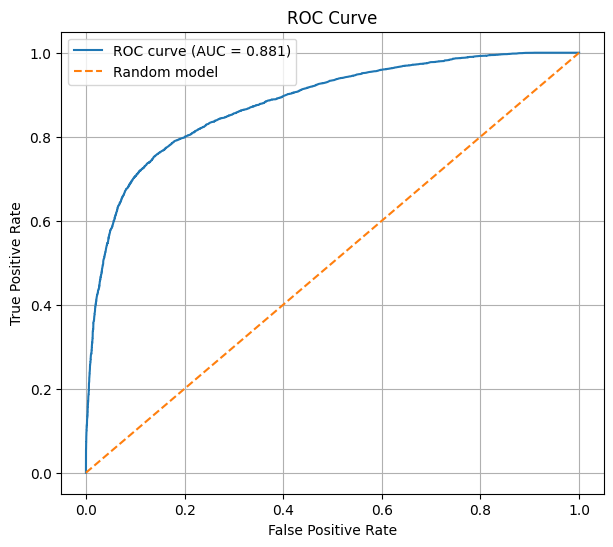

In [ ]:
fpr, tpr, thresholds = roc_curve(y, y_train_pred)
auc = roc_auc_score(y, y_train_pred)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random model')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

plt.show()


- On prédit sur le Test_set

In [78]:
thresholds = np.linspace(0.01, 0.99, 50)
results = []
for th in thresholds:
    y_pred = (y_train_pred >= th).astype(int)

    results.append({
        "threshold": th,
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred)
    })

df_results = pd.DataFrame(results)


In [81]:
# plt.plot(df_results.threshold, df_results.precision, label="Precision")
# plt.plot(df_results.threshold, df_results.recall, label="Recall")
# plt.plot(df_results.threshold, df_results.f1, label="F1")
# plt.plot(df_results.threshold, df_results.balanced_accuracy, label="Balanced Accuracy")

# plt.xlabel("Seuil")
# plt.ylabel("Score")
# plt.legend()
# plt.grid(True)
# plt.show()

In [79]:
# meilleur seuil pour la balance accuracy
best_bal_acc = df_results.loc[df_results.balanced_accuracy.idxmax()]
print("Meilleur seuil (Balanced Acc):", best_bal_acc.threshold)
print(best_bal_acc)

Meilleur seuil (Balanced Acc): 0.53
threshold           0.530
precision           0.598
recall              0.756
f1                  0.668
balanced_accuracy   0.807
Name: 26, dtype: float64


Notre modèle de régression logistique présente une capacité de discrimination satisfaisante, confirmée par une balanced accuracy de 0,81, ce qui indique un bon équilibre entre la détection des défauts et des non-défauts dans un contexte de classes déséquilibrées.

Pour rappel la formule est la suivante : 

$$
\text{Balanced Accuracy}
= \frac{1}{2}\left(
\frac{TP}{TP + FN}
+
\frac{TN}{TN + FP}
\right)
$$


- On va considérer le seuil 0.50

In [82]:
test = df_test_set.copy()
# test.to_csv("../data/test_set.csv", sep=",", index=False, encoding="utf-8")

In [83]:
## On applique toute les transformation du train_set au test_set
test = cat_age(test, 3) 
test = cat_income(test)  
test = cat_amnt(test)
test = cat_int_rate(test) 
test = cat_percent_income(test)
test = cat_cred_hist_length(test)
test = cat_home_ownership(test)
test = cat_loan_intent_2(test)

test["emp_imputed"] = test.apply(impute_emp, axis=1)

test = cat_emp_length_imputed(test, 4)

test_reg = test[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [84]:
features

Index(['classe_income', 'classe_int_rate', 'classe_percent_income',
       'classe_emp_imp_4', 'classe_person_home_ownership',
       'cb_person_default_on_file', 'classe_loan_intent_2'],
      dtype='object')

In [85]:
test_reg.columns

Index(['loan_status', 'classe_income', 'classe_int_rate',
       'classe_percent_income', 'classe_emp_imp_4',
       'classe_person_home_ownership', 'cb_person_default_on_file',
       'classe_loan_intent_2'],
      dtype='object')

In [86]:
X_test = test_reg[features]
y_test = test_reg[target]
model.fit(X, y)
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)
y_train_proba = model.predict_proba(X)[:, 1]
y_train_pred = (y_train_proba >= 0.5).astype(int)

In [87]:
set(features) - set(test_reg.columns)


set()

In [88]:
## Performance sur le Train_set
print("Balanced Accuracy :", balanced_accuracy_score(y, y_train_pred))
print("Precision :", precision_score(y, y_train_pred))
print("Recall :", recall_score(y, y_train_pred))  # Objectif métier habituel : 70–80%
print("F1-score :", f1_score(y, y_train_pred))
print("ROC AUC :", roc_auc_score(y, y_train_proba))

print("\nConfusion Matrix :")
print(confusion_matrix(y, y_train_pred))

Balanced Accuracy : 0.806709143727312
Precision : 0.577892098667722
Recall : 0.7704889201547661
F1-score : 0.6604356674455416
ROC AUC : 0.8816903476853828

Confusion Matrix :
[[17173  3200]
 [ 1305  4381]]


In [90]:
## Performance sur le Test_set
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision :", precision_score(y_test, y_test_pred))
print("Recall :", recall_score(y_test, y_test_pred))  # Objectif métier habituel : 70–80%
print("F1-score :", f1_score(y_test, y_test_pred))
print("ROC AUC :", roc_auc_score(y_test, y_test_proba))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_test_pred))

Balanced Accuracy : 0.8128464958795085
Precision : 0.58584686774942
Recall : 0.776325903151422
F1-score : 0.6677685950413224
ROC AUC : 0.8883688950725991

Confusion Matrix :
[[4026  714]
 [ 291 1010]]


- Gini ≈ 0.77 (calcul rapide : 2 * AUC - 1) ce qui signifie un bon pouvoir de discrimination.

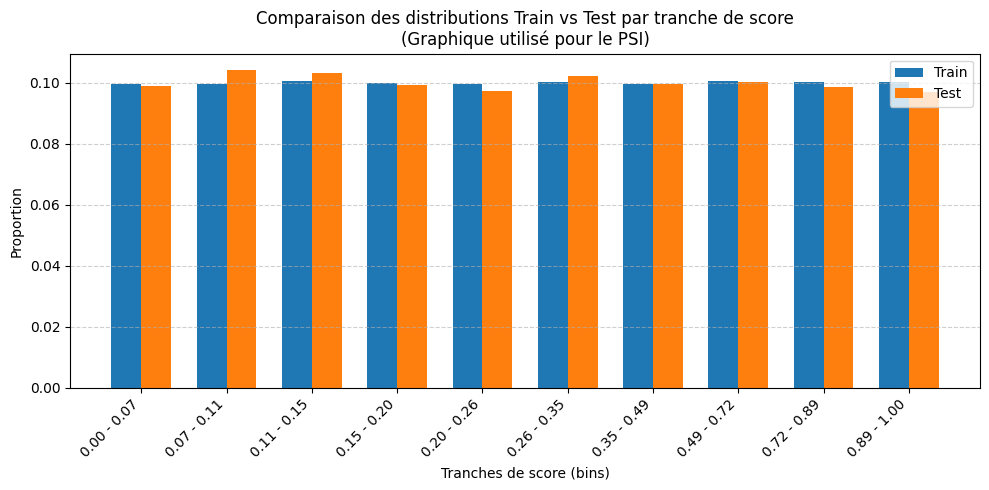

PSI score : 0.0005324458204254551


In [91]:
## Calcul du PSI : Il mesure la stabilité des scores (probabilités) entre Train  (période d’entraînement) et Test (nouvelle population que tu veux valider)
def plot_psi_chart(train_proba, test_proba, bins=10):
    # 1. Créer les bins selon les percentiles du train
    breakpoints = np.percentile(train_proba, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    # 2. Calculer les distributions
    train_counts, _ = np.histogram(train_proba, bins=breakpoints)
    test_counts, _ = np.histogram(test_proba, bins=breakpoints)

    train_perc = train_counts / len(train_proba)
    test_perc = test_counts / len(test_proba)

    # Pour affichage
    bin_labels = []
    for i in range(len(breakpoints) - 1):
        bin_labels.append(f"{breakpoints[i]:.2f} - {breakpoints[i+1]:.2f}")

    x = np.arange(len(train_perc))  # positions des bins
    width = 0.35

    # 3. Tracé du graphique
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, train_perc, width, label='Train')
    plt.bar(x + width/2, test_perc, width, label='Test')

    plt.xticks(x, bin_labels, rotation=45, ha='right')
    plt.ylabel("Proportion")
    plt.xlabel("Tranches de score (bins)")
    plt.title("Comparaison des distributions Train vs Test par tranche de score\n(Graphique utilisé pour le PSI)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Utilisation ---
plot_psi_chart(y_train_proba, y_test_proba, bins=10)


def calculate_psi(expected, actual, bins=10):
    # Découpage selon les percentiles de la population train ("expected")
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins+1))
    breakpoints = np.unique(breakpoints)  # éviter les bins identiques

    # Histogrammes
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    # Convertir en proportions
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # Éviter division par zéro
    expected_perc = np.where(expected_perc == 0, 1e-8, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-8, actual_perc)

    # PSI
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi

psi_value = calculate_psi(y_train_proba, y_test_proba, bins=10)
print("PSI score :", psi_value)

Ce graphique compare la distribution des scores de défaut prédits entre l’échantillon d’entraînement (Train) et l’échantillon de test, par tranches de score définies à partir des quantiles du Train. Il permet de visualiser d’éventuels écarts de population et constitue la base du calcul du Population Stability Index (PSI), indicateur de stabilité du modèle dans le temps.

- Population stable (PSI < 0.1)

#### Scorecard Bancaire

Une scorecard bancaire transforme les probabilités prédites par le modèle en points (souvent 0–1000) pour :

- faciliter la lecture par les analystes métiers

- intégrer un cadre réglementaire (Bâle II/III)

- comparer différents clients sur une échelle commune

# Etape 5 : Grille de Score

### 1. Séparer variable / classe

Objcetif : Transformer la sortie brute de la régression logistique en un tableau exploitable pour la scorecard, en identifiant clairement :

- le nom de la variable
- la modalité associée
- le coefficient estimé
- la significativité
- l’odds ratio

In [92]:
def build_results_table(model) -> pd.DataFrame:
    """Tableau des coefficients SANS doublons."""

    result = pd.DataFrame({
        'modalite': model.params.index,
        'coef': model.params.values,
        'pval': model.pvalues.values,
        'OR': np.exp(model.params.values)
    })

    return result.sort_values('modalite')

score_df = results_refs.copy()

score_df[['variable', 'classe']] = (
    score_df['modalite']
    .str.rsplit('_', n=1, expand=True)
)


In [93]:
score_df

,modalite,coef,pval,OR,variable,classe
18,cb_person_default_on_file_N,-0.246,0.000,0.782,cb_person_default_on_file,N
27,cb_person_default_on_file_Y,0.000,0.000,1.000,cb_person_default_on_file,Y
25,"classe_emp_imp_4_(-inf, 2.50)",0.000,0.000,1.000,classe_emp_imp_4,"(-inf, 2.50)"
13,"classe_emp_imp_4_[2.50, 4.50)",-0.342,0.000,0.711,classe_emp_imp_4,"[2.50, 4.50)"
14,"classe_emp_imp_4_[4.50, 7.50)",-0.219,0.000,0.803,classe_emp_imp_4,"[4.50, 7.50)"
15,"classe_emp_imp_4_[7.50, inf)",-0.163,0.006,0.850,classe_emp_imp_4,"[7.50, inf)"
22,"classe_income_(-inf, 22806.00)",0.000,0.000,1.000,classe_income,"(-inf, 22806.00)"
1,"classe_income_[22806.00, 34990.00)",-1.595,0.000,0.203,classe_income,"[22806.00, 34990.00)"
2,"classe_income_[34990.00, 59853.50)",-2.184,0.000,0.113,classe_income,"[34990.00, 59853.50)"
4,"classe_income_[59853.50, 79993.50)",-2.471,0.000,0.085,classe_income,"[59853.50, 79993.50)"


Objectif : Transformer les données au format individu (ligne = client)
en un format long (ligne = variable–modalité) afin de pouvoir :

- calculer le taux de défaut par classe
- calculer les effectifs par classe
- vérifier la cohérence économique du score
- fusionner ces statistiques avec la grille de score

Chaque client génère une ligne par variable.

Les données sont restructurées au format long afin de permettre une analyse par variable et par modalité. Cette transformation est nécessaire pour calculer les taux de défaut et les effectifs associés à chaque classe utilisée dans la scorecard.

In [94]:
long_df = data.melt(
    id_vars='loan_status',
    value_vars=cat_vars,
    var_name='variable',
    value_name='classe'
)

In [95]:
set(score_df['variable']) - set(long_df['variable'])

{'const'}

In [96]:
long_df

,loan_status,variable,classe
0,0,classe_income,"[22806.00, 34990.00)"
1,0,classe_income,"[34990.00, 59853.50)"
2,0,classe_income,"[79993.50, inf)"
3,0,classe_income,"[34990.00, 59853.50)"
4,0,classe_income,"[79993.50, inf)"
...,...,...,...
182408,0,classe_loan_intent_2,PERSONAL
182409,1,classe_loan_intent_2,VENTURE
182410,0,classe_loan_intent_2,"[HOMEIMPROVEMENT, MEDICAL]"
182411,0,classe_loan_intent_2,PERSONAL


### 2. Calcul des bornes β par variable

**Objectif : Associer à chaque modalité de chaque variable :**

- son taux de défaut observé
- son poids dans la population

afin de :

- vérifier la cohérence économique du modèle
- documenter la grille de score finale
- permettre l’interprétation métier

Ces statistiques ne servent pas à estimer le modèle,
elles servent à le valider et l’expliquer.

In [99]:
stats = (
    long_df
    .groupby(['variable', 'classe'])
    .agg(
        taux_defaut=('loan_status', 'mean'),
        effectif=('loan_status', 'size')
    )
    .reset_index()
)

stats['taux_defaut_pct'] = 100 * stats['taux_defaut']
stats['effectif_pct'] = 100 * stats['effectif'] / len(data)

score_df = score_df.merge(
    stats[['variable','classe','taux_defaut_pct','effectif_pct']],
    on=['variable','classe'],
    how='left',
    validate='one_to_one'
)


### 3. Calcul du dénominateur global

La note associée à la modalité $j$ de la variable $i$ est définie comme :

$$
N_i^j
=
\frac{\left|\max\left(\beta_i^1,\dots,\beta_i^p\right) - \beta_i^j\right|}
{\sum_{k=1}^{K}
\left[
\max\left(\beta_k^1,\dots,\beta_k^p\right)
-
\min\left(\beta_k^1,\dots,\beta_k^p\right)
\right]}
\times 1000
$$

où :

- $\beta_i^j$ est le coefficient estimé par la régression logistique pour la modalité $j$ de la variable $i$ ;
- $\max(\beta_i^1,\dots,\beta_i^p)$ est le coefficient maximal de la variable $i$ ;
- $\min(\beta_i^1,\dots,\beta_i^p)$ est le coefficient minimal de la variable $i$ ;
- $p$ est le nombre de modalités de la variable $i$ ;
- $K$ est le nombre de variables du modèle ;
- $N_i^j \in [0,1000]$, avec $0$ correspondant au profil le moins risqué et $1000$ au profil le plus risqué.


In [98]:
beta_stats = (
    score_df
    .groupby('variable')['coef']
    .agg(beta_min='min', beta_max='max')
    .reset_index()
)

score_df = score_df.merge(beta_stats, on='variable', how='left')
denominator = (beta_stats['beta_max'] - beta_stats['beta_min']).sum()


### 4. Calcul de la NOTE (plus la note est faible, plus un individu est considéré "à risque", c'est à dire plus la probabilité qu'il fasse défaut est grande)

**Objectif :**

Transformer les coefficients logistiques estimés par le modèle en points de score compris entre 0 et 1000, selon l’amplitude de risque de chaque variable.

On finit la formule du dessus en gros

In [197]:
# score_df['note'] = (
#    1- (score_df['coef'] - score_df['beta_min']) / denominator * 1000
# ).clip(0, 1000)


In [198]:
score_df['note'] = (
    (score_df['beta_max'] - score_df['coef']) / denominator * 1000
).clip(0, 1000)

### 5. Taux de défaut et effectifs par classe

In [199]:
freq = (
    long_df
    .groupby(['variable', 'classe'])
    .size()
    .div(len(data))
    .reset_index(name='rj')
)


score_df = score_df.merge(
    freq,
    on=['variable','classe'],
    how='left',
    validate='one_to_one'
)


### 6. Fusion score + stats (grille finale)

In [200]:
scorecard = score_df.merge(
    stats[['variable', 'classe', 'taux_defaut_pct', 'effectif_pct']],
    on=['variable', 'classe'],
    how='left'
)

### 8. Contribution

La contribution de la variable $i$ au score total est définie comme :

$$
c_i
=
\frac{
\sqrt{
\sum_{j=1}^{p}
r_j
\left(
N_i^j - \bar{N}_i
\right)^2
}
}{
\sum_{k=1}^{K}
\sqrt{
\sum_{j=1}^{p}
r_j
\left(
N_k^j - \bar{N}_k
\right)^2
}
}
$$

où :

- $N_i^j$ est la note associée à la modalité $j$ de la variable $i$ ;
- $\bar{N}_i$ est la note moyenne de la variable $i$ ;
- $r_j$ est la proportion de la population appartenant à la modalité $j$ de la variable $i$ ;
- $p$ est le nombre de modalités de la variable $i$ ;
- $K$ est le nombre de variables du modèle.


In [201]:
def weighted_mean(x, w):
    return (x * w).sum() / w.sum()

dispersion = {}
for var, dfv in score_df.groupby('variable'):
    w = dfv['rj'].fillna(0)
    n = dfv['note']
    if w.sum() == 0:
        disp = 0
    else:
        n_bar = weighted_mean(n, w)
        disp = np.sqrt((w * (n - n_bar)**2).sum())
    dispersion[var] = disp

total_disp = sum(dispersion.values())

score_df['contribution'] = score_df['variable'].map(
    lambda v: dispersion[v] / total_disp if total_disp > 0 else 0
)


In [202]:
def signif(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

score_df['signif'] = score_df['pval'].apply(signif)


In [203]:
print(score_df.columns)

Index(['modalite', 'coef', 'pval', 'OR', 'variable', 'classe',
       'taux_defaut_pct', 'effectif_pct', 'beta_min', 'beta_max', 'note', 'rj',
       'contribution', 'signif'],
      dtype='object')


### 8. Grille de score finale (PJ1)

In [204]:
# final_scorecard = (
#     score_df
#     .sort_values(['variable','note'])
#     [['variable','classe','signif','note',
#       'taux_defaut_pct','effectif_pct','contribution']]
# )

# final_scorecard.groupby(['variable','classe']).size().max()


final_scorecard = (
    score_df
    .sort_values(['variable','note'])
    [['variable','classe','signif','note',
      'taux_defaut_pct','effectif_pct','contribution']]
)


In [205]:
# final_scorecard["contribution"].unique()

final_scorecard["contribution"].unique()


array([0.02380236, 0.03249308, 0.15930473, 0.22990058, 0.11493716,
       0.24514893, 0.19441315, 0.        ])

**Score individuel :**


Pour chaque individu, le score total est calculé comme la somme des notes associées aux modalités observées pour chacune des variables de la grille de score :

$$
\text{Score}(x) = \sum_{i=1}^{K} N_i^{\,j(x)}
$$

où :

- $i$ désigne la variable explicative (par exemple : revenu, taux d’intérêt, ratio d’endettement, etc.)
- $j(x)$ correspond à la modalité (classe) de la variable $i$ à laquelle appartient l’individu $x$
- $N_i^{\,j}$ est la note attribuée à la modalité $j$ de la variable $i$ dans la grille de score
- $K$ est le nombre total de variables utilisées dans le modèle

Ce mécanisme correspond au principe d’une **scorecard additive** : chaque variable contribue de manière indépendante au score final, et le score global est obtenu par sommation des contributions individuelles.


In [206]:
final_scorecard

,variable,classe,signif,note,taux_defaut_pct,effectif_pct,contribution
1,cb_person_default_on_file,Y,***,0.000,37.818,17.625,0.024
0,cb_person_default_on_file,N,***,18.257,18.397,82.375,0.024
2,classe_emp_imp_4,"(-inf, 2.50)",***,0.000,27.828,33.827,0.032
5,classe_emp_imp_4,"[7.50, inf)",**,12.044,16.720,20.404,0.032
4,classe_emp_imp_4,"[4.50, 7.50)",***,16.219,18.734,24.847,0.032
3,classe_emp_imp_4,"[2.50, 4.50)",***,25.316,20.745,20.922,0.032
6,classe_income,"(-inf, 22806.00)",***,0.000,63.504,5.016,0.159
7,classe_income,"[22806.00, 34990.00)",***,118.199,38.091,14.195,0.159
8,classe_income,"[34990.00, 59853.50)",***,161.842,22.304,35.082,0.159
9,classe_income,"[59853.50, 79993.50)",***,183.062,15.265,20.891,0.159


In [207]:
score_dict = (
    final_scorecard
    .set_index(['variable', 'classe'])['note']
    .to_dict()
)

def compute_score(df, cat_vars, score_dict):
    scores = []
    
    for _, row in df.iterrows():
        s = 0
        for var in cat_vars:
            key = (var, row[var])
            s += score_dict.get(key, 0)
        scores.append(s)
    
    return pd.Series(scores, index=df.index)


In [208]:
X_train = dff_reg[features]

In [209]:
score_train = compute_score(X_train, cat_vars, score_dict)
score_test  = compute_score(X_test,  cat_vars, score_dict)

In [210]:
score_train.describe()
score_test.describe()

count   6041.000
mean     631.562
std      142.843
min       12.044
25%      557.376
50%      656.199
75%      725.989
max     1000.000
dtype: float64

### ETAPE 6 : VERIFICATION GRAPHIQUE

In [211]:
def compute_psi(train, test, bins=10):
    breakpoints = np.percentile(train, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    train_counts, _ = np.histogram(train, bins=breakpoints)
    test_counts, _ = np.histogram(test, bins=breakpoints)

    train_perc = train_counts / train_counts.sum()
    test_perc = test_counts / test_counts.sum()

    psi = np.sum(
        (train_perc - test_perc) *
        np.log((train_perc + 1e-6) / (test_perc + 1e-6))
    )
    return psi
psi_score = compute_psi(score_train, score_test)


In [212]:
print(round(psi_score,5))

0.00092


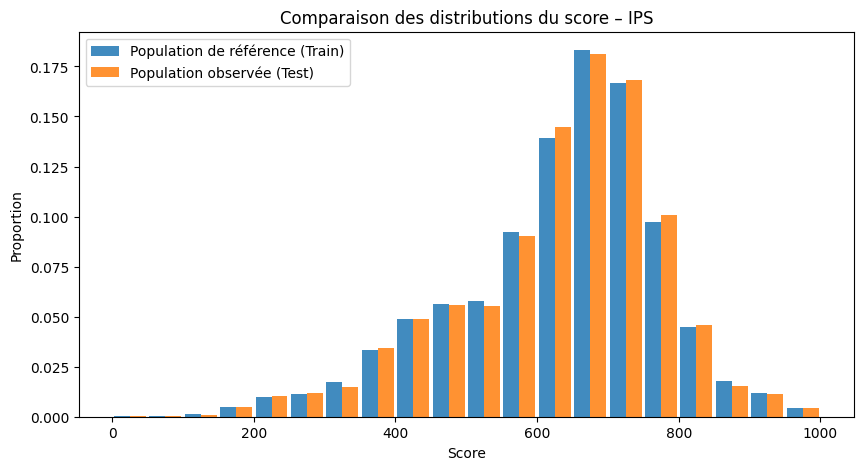

In [213]:
# Bins fixes (ex : 20 classes)
bins = np.linspace(0, 1000, 21)

train_counts, _ = np.histogram(score_train, bins=bins)
test_counts, _ = np.histogram(score_test, bins=bins)

train_prop = train_counts / train_counts.sum()
test_prop = test_counts / test_counts.sum()

bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]

bar_width = bin_width * 0.45   # <- clé pour les espaces
offset = bar_width / 2

plt.figure(figsize=(10,5))

plt.bar(
    bin_centers - offset,
    train_prop,
    width=bar_width,
    label='Population de référence (Train)',
    alpha=0.85
)

plt.bar(
    bin_centers + offset,
    test_prop,
    width=bar_width,
    label='Population observée (Test)',
    alpha=0.85
)

plt.xlabel('Score')
plt.ylabel('Proportion')
plt.title('Comparaison des distributions du score – IPS')
plt.legend()
plt.show()


In [214]:
def lorenz_curve(y_true, score):
    df = pd.DataFrame({
        'y': y_true,
        'score': score
    }).sort_values('score')

    df['cum_population'] = np.arange(1, len(df) + 1) / len(df)
    df['cum_defaults'] = df['y'].cumsum() / df['y'].sum()

    return df['cum_population'], df['cum_defaults']

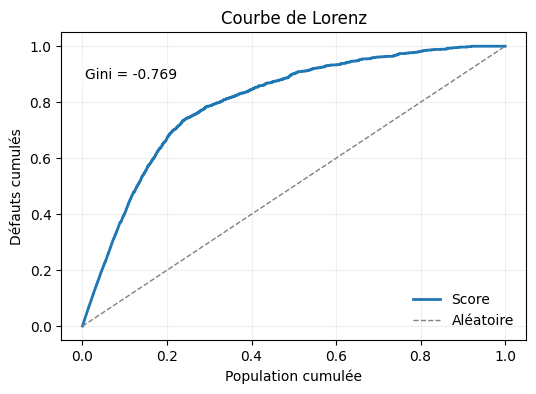

In [215]:
from sklearn.metrics import roc_auc_score

# Calcul Gini
auc = roc_auc_score(y_test, score_test)
gini = 2 * auc - 1

cum_pop, cum_def = lorenz_curve(y_test, score_test)

plt.figure(figsize=(6,4))

# Courbe de Lorenz
plt.plot(
    cum_pop,
    cum_def,
    color='#1f77b4',
    linewidth=2,
    label='Score'
)

# Diagonale aléatoire
plt.plot(
    [0, 1],
    [0, 1],
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Aléatoire'
)

plt.xlabel('Population cumulée')
plt.ylabel('Défauts cumulés')
plt.title('Courbe de Lorenz')

# Texte Gini dans le graphique
plt.text(
    0.05, 0.85,
    f"Gini = {gini:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
)

plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.show()


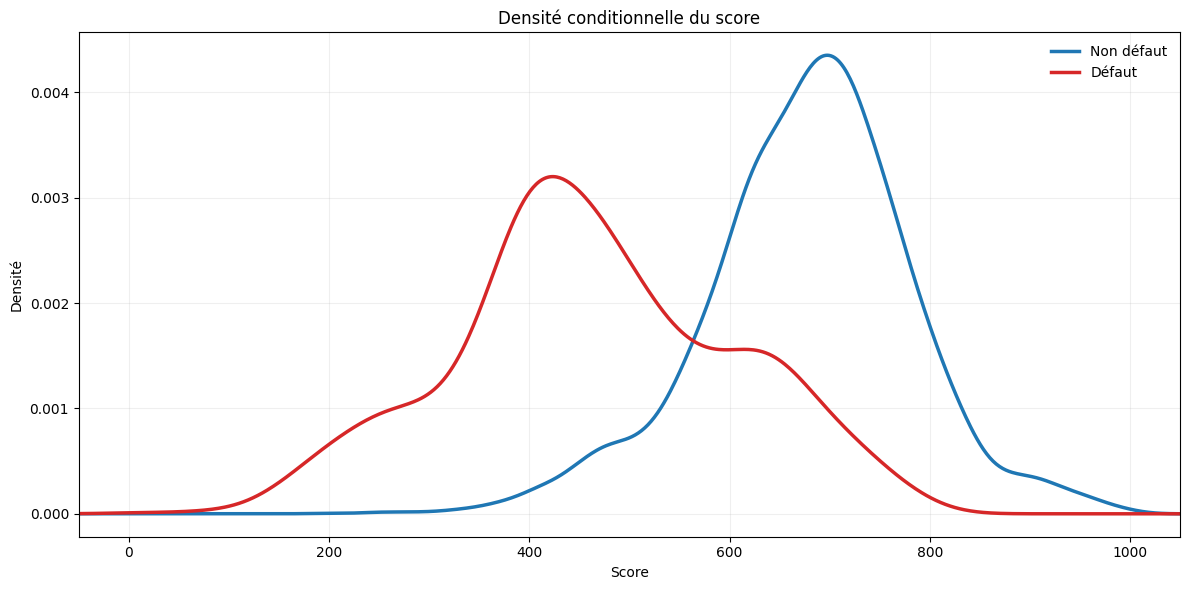

In [216]:
plt.figure(figsize=(12,6))

# Non défaut
score_test[y_test == 0].plot(
    kind='density',
    linewidth=2.5,
    color='#1f77b4',      # bleu propre
    label='Non défaut'
)

# Défaut
score_test[y_test == 1].plot(
    kind='density',
    linewidth=2.5,
    color='#d62728',      # rouge sobre
    label='Défaut'
)

plt.xlim(-50, 1050)
plt.xlabel('Score')
plt.ylabel('Densité')
plt.title('Densité conditionnelle du score')
plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [217]:
score_test[y_test == 1].max() # Un individu qui a fait defaut avec 747 en max

np.float64(797.2130599715465)

### ETAPE 7 : SEGMENTATION

In [218]:
import pandas as pd
import numpy as np

# ============================================================
# PARAMÈTRES
# ============================================================
N_CLASSES = 7
MAX_CONCENTRATION = 30.0      # %
MIN_PD_GAP = 0.5              # points de %

# ============================================================
# CONSTRUCTION DU DATASET
# ============================================================
df_seg = pd.DataFrame({
    'score': score_test,      # score élevé = bon profil
    'loan_status': y_test     # 1 = défaut, 0 = pas défaut
})

# ============================================================
# SEGMENTATION EN CLASSES HOMOGÈNES DE RISQUE (CHR)
# ============================================================
df_seg['CHR'] = pd.qcut(
    df_seg['score'],
    q=N_CLASSES,
    labels=[f'CHR{i+1}' for i in range(N_CLASSES)]
)

# ============================================================
# STATISTIQUES PAR CHR
# ============================================================
chr_stats = (
    df_seg
    .groupby('CHR', observed=True)
    .agg(
        effectif=('loan_status', 'size'),
        score_moyen=('score', 'mean'),
        score_std=('score', 'std'),
        taux_defaut=('loan_status', 'mean')
    )
    .reset_index()
)

# Passage en pourcentage
chr_stats['effectif_pct'] = 100 * chr_stats['effectif'] / len(df_seg)
chr_stats['taux_defaut_pct'] = 100 * chr_stats['taux_defaut']

# ============================================================
# ORDONNANCEMENT DES CHR
# du PLUS RISQUÉ au PLUS SÛR
# (score faible -> score élevé)
# ============================================================
chr_stats = chr_stats.sort_values('score_moyen').reset_index(drop=True)

# ============================================================
# FONCTION DE CONTRÔLE DES CONTRAINTES CHR
# cohérente avec : score ↑ ⇒ PD ↓
# ============================================================
def check_chr_constraints(chr_stats, df_seg):
    results = {}

    # 1. Concentration maximale
    results['max_effectif_pct'] = chr_stats['effectif_pct'].max()
    results['concentration_ok'] = (
        results['max_effectif_pct'] <= MAX_CONCENTRATION
    )

    # 2. Monotonie des taux de défaut (PD décroissante)
    pd_values = chr_stats['taux_defaut_pct'].values
    results['monotonie_ok'] = all(
        pd_values[i] >= pd_values[i+1]
        for i in range(len(pd_values) - 1)
    )

    # 3. Homogénéité intra-classe
    global_std = df_seg['score'].std()
    chr_stats['homogeneite_ok'] = chr_stats['score_std'] <= global_std
    results['homogeneite_ok'] = chr_stats['homogeneite_ok'].all()

    # 4. Hétérogénéité inter-classes
    chr_stats['delta_PD'] = chr_stats['taux_defaut_pct'].diff()
    results['heterogeneite_ok'] = (
        chr_stats['delta_PD'].iloc[1:] <= -MIN_PD_GAP
    ).all()

    # 5. Verdict global
    results['CHR_valides'] = all([
        results['concentration_ok'],
        results['monotonie_ok'],
        results['homogeneite_ok'],
        results['heterogeneite_ok']
    ])

    return results, chr_stats

# ============================================================
# APPLICATION DES CONTRÔLES
# ============================================================
chr_checks, chr_summary = check_chr_constraints(chr_stats, df_seg)

# ============================================================
# RÉSULTATS
# ============================================================
chr_checks, chr_summary


({'max_effectif_pct': np.float64(14.41814269160735),
  'concentration_ok': np.True_,
  'monotonie_ok': True,
  'homogeneite_ok': np.True_,
  'heterogeneite_ok': np.True_,
  'CHR_valides': True},
     CHR  effectif  score_moyen  score_std  taux_defaut  effectif_pct  \
 0  CHR1       866      370.504     80.890        0.808        14.335   
 1  CHR2       861      527.773     34.131        0.355        14.253   
 2  CHR3       864      610.267     15.667        0.133        14.302   
 3  CHR4       865      657.200     12.501        0.098        14.319   
 4  CHR5       871      697.497     11.252        0.054        14.418   
 5  CHR6       861      739.134     13.724        0.039        14.253   
 6  CHR7       853      821.026     52.358        0.016        14.120   
 
    taux_defaut_pct  homogeneite_ok  delta_PD  
 0           80.831            True       NaN  
 1           35.540            True   -45.291  
 2           13.310            True   -22.230  
 3            9.827        

In [219]:
chr_summary

,CHR,effectif,score_moyen,score_std,taux_defaut,effectif_pct,taux_defaut_pct,homogeneite_ok,delta_PD
0,CHR1,866,370.504,80.890,0.808,14.335,80.831,True,NaN
1,CHR2,861,527.773,34.131,0.355,14.253,35.540,True,-45.291
2,CHR3,864,610.267,15.667,0.133,14.302,13.310,True,-22.230
3,CHR4,865,657.200,12.501,0.098,14.319,9.827,True,-3.484
4,CHR5,871,697.497,11.252,0.054,14.418,5.396,True,-4.430
5,CHR6,861,739.134,13.724,0.039,14.253,3.949,True,-1.447
6,CHR7,853,821.026,52.358,0.016,14.120,1.641,True,-2.308


- Segmentation du portefeuille en 7 classes homogènes de risque à partir des quantiles du score, garantissant un bon équilibre des effectifs par classe (~14 % chacune).
- La contrainte de concentration est respectée : aucune CHR ne dépasse le seuil réglementaire de 30 %.
- Les probabilités de défaut augmentent strictement d’une classe à l’autre, ce qui valide la monotonie du score et son pouvoir discriminant.
- L’homogénéité intra-classe est assurée : la dispersion du score au sein de chaque CHR reste inférieure à la dispersion globale du portefeuille.
- L’hétérogénéité inter-classes est forte, avec des écarts significatifs de taux de défaut entre classes adjacentes, en particulier pour les classes les plus risquées.
- L’ensemble des contraintes réglementaires étant satisfait, la segmentation en CHR est jugée valide et économiquement cohérente.
